In [ ]:
!pip install scikit-optimize

In [ ]:
#IMPORTAR AS BIBLIOTECAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from skopt.searchcv import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [ ]:
# LER DATASET

url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#LIMPEZA

df.drop(['customerID'], axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [ ]:
# SEPARAR FEATURES E TARGET

X = df.drop('Churn', axis=1)
y = df['Churn']


In [ ]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


In [ ]:
# SEPARAR EM TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# PRÉ-PROCESSAMENTO
colunas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns
colunas_categoricas = X_train.select_dtypes(include=['object']).columns

transformador_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessador = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, colunas_numericas),
        ('cat', transformador_categorico, colunas_categoricas)
    ])

In [ ]:
#CRIAÇÃO DE MODELO BASE

knn_baseline = Pipeline(steps=[('preprocessor', preprocessador),
                              ('knn', KNeighborsClassifier())])

knn_baseline.fit(X_train, y_train)

#Acc de treino
y_pred_treino = knn_baseline.predict(X_train)
acc_treino = accuracy_score(y_train, y_pred_treino)

#Acc de teste
y_pred_teste = knn_baseline.predict(X_test)
acc_teste = accuracy_score(y_test, y_pred_teste)

#validação cruzada
cv_scores = cross_val_score(knn_baseline, X_train, y_train, cv=5, scoring='accuracy')

print(f'Acurácia de treino: {acc_treino}')
print(f'Acurácia de teste: {acc_teste}')
print(f'Acurácia de validação cruzada: {np.round(cv_scores, 3)}')
print(f'Desvio padrão da acurácia de validação cruzada: {np.round(np.std(cv_scores), 3)}')

print(classification_report(y_test, y_pred_teste))



Acurácia de treino: 0.8325883787078423
Acurácia de teste: 0.7663507109004739
Acurácia de validação cruzada: [0.771 0.754 0.776 0.745 0.749]
Desvio padrão da acurácia de validação cruzada: 0.012
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1549
           1       0.56      0.57      0.56       561

    accuracy                           0.77      2110
   macro avg       0.70      0.70      0.70      2110
weighted avg       0.77      0.77      0.77      2110



In [ ]:
# HIPER PARÂMETROS

# Grid Search
parametros = {
    'knn__n_neighbors': range(1, 31),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(knn_baseline, param_grid=parametros, cv=5, scoring='f1_macro')
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)





# Random Search
# bayes Search

{'knn__metric': 'manhattan', 'knn__n_neighbors': 29, 'knn__weights': 'uniform'}
0.7338572225428339


In [ ]:
train_accuracies = []
test_accuracies = []

for k in range(1, 51):
    knn_model = Pipeline(steps=[('preprocessor', preprocessador),
                                ('knn', KNeighborsClassifier(n_neighbors=k))])

    knn_model.fit(X_train, y_train)

    y_pred_train = knn_model.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    train_accuracies.append(train_acc)

    y_pred_test = knn_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_accuracies.append(test_acc)

print("Accuracies calculated for k from 1 to 50.")

Accuracies calculated for k from 1 to 50.


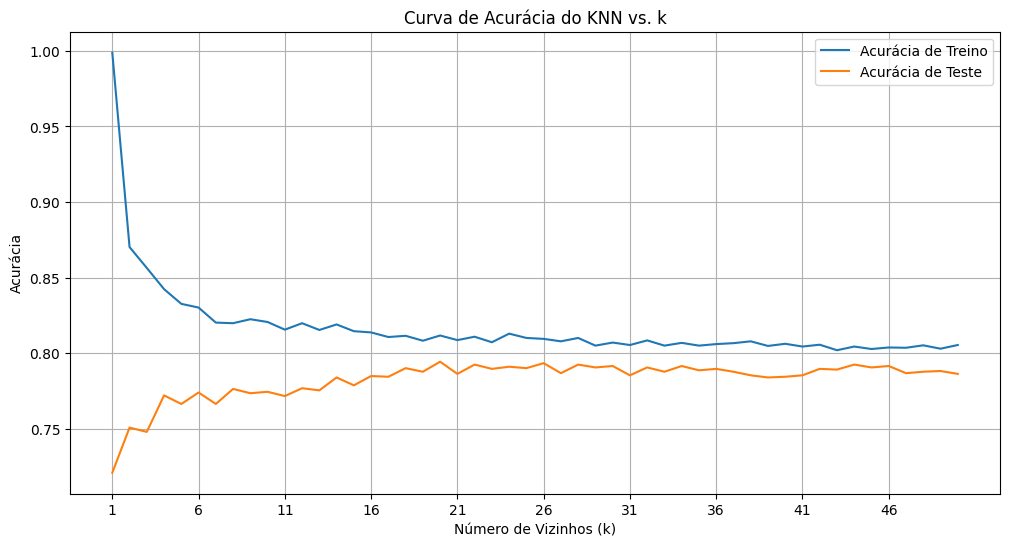

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 51), train_accuracies, label='Acurácia de Treino')
plt.plot(range(1, 51), test_accuracies, label='Acurácia de Teste')
plt.title('Curva de Acurácia do KNN vs. k')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia')
plt.xticks(range(1, 51, 5))
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# random search

parametros = {
    'knn__n_neighbors': range(1, 41),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

random = RandomizedSearchCV(knn_baseline, parametros, cv=5, scoring='f1_macro', n_iter=20)
random.fit(X_train, y_train)
print(random.best_params_)
print(random.best_score_)

{'knn__weights': 'uniform', 'knn__n_neighbors': 27, 'knn__metric': 'euclidean'}
0.7337458105193508


In [ ]:
# bayes search

parametros = {
    'knn__n_neighbors': Integer(1,100),
    'knn__weights': Categorical(['uniform', 'distance']),
    'knn__metric': Categorical(['euclidean', 'manhattan'])
}

bayes = BayesSearchCV(knn_baseline, parametros, cv=5, scoring='f1_macro', n_iter=20, n_jobs=-1)
bayes.fit(X_train, y_train)
print(bayes.best_params_)
print(bayes.best_score_)


OrderedDict({'knn__metric': 'manhattan', 'knn__n_neighbors': 40, 'knn__weights': 'uniform'})
0.7368535285797695


In [ ]:
#CRIAÇÃO DE MODELO OTIMIZADO

knn_baseline = Pipeline(steps=[('preprocessor', preprocessador),
                              ('knn', KNeighborsClassifier(metric='manhattan', n_neighbors= 40, weights= 'uniform'))])

knn_baseline.fit(X_train, y_train)

#Acc de treino
y_pred_treino = knn_baseline.predict(X_train)
acc_treino = accuracy_score(y_train, y_pred_treino)

#Acc de teste
y_pred_teste = knn_baseline.predict(X_test)
acc_teste = accuracy_score(y_test, y_pred_teste)

#validação cruzada
cv_scores = cross_val_score(knn_baseline, X_train, y_train, cv=5, scoring='accuracy')

print(f'Acurácia de treino: {acc_treino}')
print(f'Acurácia de teste: {acc_teste}')
print(f'Acurácia de validação cruzada: {np.round(cv_scores, 3)}')
print(f'Desvio padrão da acurácia de validação cruzada: {np.round(np.std(cv_scores), 3)}')

print(classification_report(y_test, y_pred_teste))



Acurácia de treino: 0.8116619260463226
Acurácia de teste: 0.790521327014218
Acurácia de validação cruzada: [0.792 0.798 0.819 0.8   0.787]
Desvio padrão da acurácia de validação cruzada: 0.011
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1549
           1       0.61      0.58      0.60       561

    accuracy                           0.79      2110
   macro avg       0.73      0.72      0.73      2110
weighted avg       0.79      0.79      0.79      2110



In [ ]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


In [ ]:
# UNDERSAMPLING (reduzir as observações da classe majoritária)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as PipelineImb
from collections import Counter

#definir a estratégia: undersampling
undersampling = RandomUnderSampler(random_state=42)

#criar um pipeline com undersampling envolvido
knn_undersampling = PipelineImb(steps=[('preprocessor', preprocessador),
                                       ('undersampler', undersampling),
                                       ('knn', KNeighborsClassifier(metric='manhattan', n_neighbors= 40, weights= 'uniform'))
                                       ])

# treina o modelo

knn_undersampling.fit(X_train, y_train)

# verifica métricas
#Acc de treino
y_pred_treino = knn_undersampling.predict(X_train)
acc_treino = accuracy_score(y_train, y_pred_treino)

#Acc de teste
y_pred_teste = knn_undersampling.predict(X_test)
acc_teste = accuracy_score(y_test, y_pred_teste)

#validação cruzada
cv_scores = cross_val_score(knn_undersampling, X_train, y_train, cv=5, scoring='accuracy')

print(f'Acurácia de treino: {acc_treino}')
print(f'Acurácia de teste: {acc_teste}')
print(f'Acurácia de validação cruzada: {np.round(cv_scores, 3)}')
print(f'Desvio padrão da acurácia de validação cruzada: {np.round(np.std(cv_scores), 3)}')

print(classification_report(y_test, y_pred_teste))


Acurácia de treino: 0.7108898821617229
Acurácia de teste: 0.6819905213270142
Acurácia de validação cruzada: [0.69  0.695 0.736 0.699 0.705]
Desvio padrão da acurácia de validação cruzada: 0.016
              precision    recall  f1-score   support

           0       0.91      0.63      0.74      1549
           1       0.45      0.83      0.58       561

    accuracy                           0.68      2110
   macro avg       0.68      0.73      0.66      2110
weighted avg       0.79      0.68      0.70      2110



In [ ]:
# OVERSAMPLING - randômica (eu copio e colo exemplos da classe minoritária)

from imblearn.over_sampling import RandomOverSampler

over_random = RandomOverSampler(random_state = 42)

#criar um pipeline com undersampling envolvido
knn_overersampling = PipelineImb(steps=[('preprocessor', preprocessador),
                                       ('undersampler', over_random),
                                       ('knn', KNeighborsClassifier(metric='manhattan', n_neighbors= 40, weights= 'uniform'))
                                       ])

# treina o modelo

knn_overersampling.fit(X_train, y_train)

# verifica métricas
#Acc de treino
y_pred_treino = knn_overersampling.predict(X_train)
acc_treino = accuracy_score(y_train, y_pred_treino)

#Acc de teste
y_pred_teste = knn_overersampling.predict(X_test)
acc_teste = accuracy_score(y_test, y_pred_teste)

#validação cruzada
cv_scores = cross_val_score(knn_overersampling, X_train, y_train, cv=5, scoring='accuracy')

print(f'Acurácia de treino: {acc_treino}')
print(f'Acurácia de teste: {acc_teste}')
print(f'Acurácia de validação cruzada: {np.round(cv_scores, 3)}')
print(f'Desvio padrão da acurácia de validação cruzada: {np.round(np.std(cv_scores), 3)}')

print(classification_report(y_test, y_pred_teste))

Acurácia de treino: 0.7308004876066639
Acurácia de teste: 0.6957345971563981
Acurácia de validação cruzada: [0.706 0.699 0.74  0.718 0.702]
Desvio padrão da acurácia de validação cruzada: 0.015
              precision    recall  f1-score   support

           0       0.91      0.65      0.76      1549
           1       0.46      0.82      0.59       561

    accuracy                           0.70      2110
   macro avg       0.68      0.73      0.67      2110
weighted avg       0.79      0.70      0.71      2110



In [ ]:
# OVERSAMPLING - SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 42)

#criar um pipeline com undersampling envolvido
knn_overersampling = PipelineImb(steps=[('preprocessor', preprocessador),
                                       ('undersampler', smote),
                                       ('knn', KNeighborsClassifier(metric='manhattan', n_neighbors= 40, weights= 'uniform'))
                                       ])

# treina o modelo

knn_overersampling.fit(X_train, y_train)

# verifica métricas
#Acc de treino
y_pred_treino = knn_overersampling.predict(X_train)
acc_treino = accuracy_score(y_train, y_pred_treino)

#Acc de teste
y_pred_teste = knn_overersampling.predict(X_test)
acc_teste = accuracy_score(y_test, y_pred_teste)

#validação cruzada
cv_scores = cross_val_score(knn_overersampling, X_train, y_train, cv=5, scoring='accuracy')

print(f'Acurácia de treino: {acc_treino}')
print(f'Acurácia de teste: {acc_teste}')
print(f'Acurácia de validação cruzada: {np.round(cv_scores, 3)}')
print(f'Desvio padrão da acurácia de validação cruzada: {np.round(np.std(cv_scores), 3)}')

print(classification_report(y_test, y_pred_teste))

Acurácia de treino: 0.7476635514018691
Acurácia de teste: 0.7066350710900474
Acurácia de validação cruzada: [0.733 0.724 0.763 0.728 0.718]
Desvio padrão da acurácia de validação cruzada: 0.016
              precision    recall  f1-score   support

           0       0.90      0.67      0.77      1549
           1       0.47      0.80      0.59       561

    accuracy                           0.71      2110
   macro avg       0.69      0.74      0.68      2110
weighted avg       0.79      0.71      0.72      2110



In [ ]:
# bayes search

parametros = {
    'knn__n_neighbors': Integer(1,100),
    'knn__weights': Categorical(['uniform', 'distance']),
    'knn__metric': Categorical(['euclidean', 'manhattan'])
}

bayes = BayesSearchCV(knn_overersampling, parametros, cv=5, scoring='f1_macro', n_iter=20, n_jobs=-1)
bayes.fit(X_train, y_train)
print(bayes.best_params_)
print(bayes.best_score_)


OrderedDict({'knn__metric': 'manhattan', 'knn__n_neighbors': 34, 'knn__weights': 'uniform'})
0.7091235507939952
